# CSG520 — Leaf disease project: A1 + A2 on Colab

Run the cells in order. **Before anything else: Runtime -> Change runtime type -> T4 GPU.**

Estimated wall clock on a T4: A2 ~25 min, A1 ~1.5 h per backbone.

## 1. Check the GPU

In [1]:
!nvidia-smi
import torch
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())

Sun Sep 13 13:36:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   41C    P8             16W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Drive and keep outputs there

Colab wipes local disk when the runtime dies. Pointing `outputs/` at Drive means
checkpoints, metrics and figures survive a disconnect.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/csg520_outputs

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!nproc

12


## 3. Upload and unzip the code

Run the cell, then pick `leaf_xai_A1_A2.zip` from your machine.
(Alternative: put the zip in Drive and use the commented line instead.)

In [3]:
%cd /content
from google.colab import files
uploaded = files.upload()          # choose leaf_xai_A1_A2.zip

# --- or, if the zip is already in Drive: ---
# !cp /content/drive/MyDrive/leaf_xai_A1_A2.zip /content/

!unzip -oq leaf_xai_A1_A2.zip
%cd /content/leaf_xai
!ls -R | head -25

/content


Saving leaf_xai_A1_A2.zip to leaf_xai_A1_A2 (1).zip
/content/leaf_xai
.:
data
kaggle.json
outputs
README.md
requirements.txt
src

./data:
classes.json
raw
splits.csv

./src:
approach1_transfer.py
approach2_handcrafted.py
config.py
data.py
features.py
gradcam.py
__pycache__
torch_data.py
utils.py

./src/__pycache__:


Send outputs to Drive instead of local disk:

In [4]:
%cd /content/leaf_xai
!rm -rf outputs && ln -s /content/drive/MyDrive/csg520_outputs outputs
!ls -ld outputs

/content/leaf_xai
lrwxrwxrwx 1 root root 37 Sep 13 13:37 outputs -> /content/drive/MyDrive/csg520_outputs


## 4. Install the two packages Colab lacks

torch, torchvision, numpy, pandas, scikit-learn, scikit-image and matplotlib are
already on Colab. Only OpenCV's headless build and joblib may need a nudge.

In [5]:
!pip install -q opencv-python-headless joblib
import cv2, skimage, sklearn, joblib
print("cv2", cv2.__version__, "| skimage", skimage.__version__, "| sklearn", sklearn.__version__)

cv2 5.0.0 | skimage 0.25.2 | sklearn 1.6.1


## 5. Get PlantVillage

Easiest route is the Kaggle API. Get `kaggle.json` from your Kaggle account page
(Settings -> API -> Create New Token), then run this cell and upload it.

If you already have the dataset in Drive, skip to the cell after next.

In [6]:
from google.colab import files
print("upload kaggle.json")
files.upload()

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

# Verify the slug on kaggle.com before running -- dataset slugs change.
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/pv --unzip

upload kaggle.json


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:49<00:00, 20.0MB/s]



Already have it in Drive? Use this instead of the cell above:

In [ ]:
# !mkdir -p /content/pv && unzip -q /content/drive/MyDrive/plantvillage.zip -d /content/pv

unzip:  cannot find or open /content/drive/MyDrive/plantvillage.zip, /content/drive/MyDrive/plantvillage.zip.zip or /content/drive/MyDrive/plantvillage.zip.ZIP.


## 6. Point `data/raw` at the class folders

PlantVillage ships `color/`, `grayscale/` and `segmented/` variants. We want
`color/`. This cell finds it (or any folder that looks like an ImageFolder root)
and symlinks it -- no copying 54k files around.

In [7]:
import pathlib, os

SEARCH_ROOT = pathlib.Path('/content/pv')

def looks_like_class_root(p: pathlib.Path) -> int:
    """Number of immediate subdirectories that actually contain images."""
    if not p.is_dir():
        return 0
    n = 0
    for d in list(p.iterdir())[:60]:
        if d.is_dir() and any(f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
                              for f in list(d.iterdir())[:5]):
            n += 1
    return n

# Prefer a folder literally named 'color'; otherwise take the richest candidate.
candidates = [p for p in SEARCH_ROOT.rglob('*') if p.is_dir()]
colour_dirs = [p for p in candidates if p.name.lower() == 'color']
best = colour_dirs[0] if colour_dirs else max(candidates, key=looks_like_class_root)
n_classes = looks_like_class_root(best)
print("using:", best, "|", n_classes, "class folders")
assert n_classes >= 2, "Could not locate the class folders -- check /content/pv by hand"

%cd /content/leaf_xai
!rm -rf data/raw
os.symlink(best, '/content/leaf_xai/data/raw')
!ls data/raw | head -5

using: /content/pv/plantvillage dataset/color | 38 class folders
/content/leaf_xai
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy


In [8]:
!ls outputs/metrics/

a1_efficientnet_b0_history.json   a2_rf_group_permutation.csv
a1_efficientnet_b0.json		  a2_rf.json
a1_resnet50_confusion_counts.csv  a2_svm_group_permutation.csv
a1_resnet50_history.json	  a2_svm.json
a1_resnet50.json		  class_distribution.csv
a1_resnet50_scratch.json	  summary_table.csv


In [11]:
!grep -c "_scratch" src/approach1_transfer.py

1


## 7. Build the shared split (run once)

Writes `data/splits.csv` and `data/classes.json`. Every approach reads these,
which is what keeps A1 and A2 comparable. Do not rerun with `--force` later --
that reshuffles the split and invalidates any results you already have.

In [9]:
# %cd /content/leaf_xai
# !python src/data.py --build --summary

/content/leaf_xai
[data] wrote /content/leaf_xai/data/splits.csv  (54305 images, 38 classes)
split
train    38013
test      8146
val       8146

Per-class distribution:
split                                               test  train  val  total
label                                                                      
Orange___Haunglongbing_(Citrus_greening)             826   3855  826   5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus               803   3750  804   5357
Soybean___healthy                                    764   3563  763   5090
Peach___Bacterial_spot                               344   1608  345   2297
Tomato___Bacterial_spot                              319   1489  319   2127
Tomato___Late_blight                                 287   1336  286   1909
Squash___Powdery_mildew                              275   1284  276   1835
Tomato___Septoria_leaf_spot                          265   1240  266   1771
Tomato___Spider_mites Two-spotted_spider_mite        252   1173  251   

## 8. Approach 2 — sanity pass first

Small and fast: confirms segmentation, feature extraction and both models run
before you commit to the full extraction.

In [ ]:
!python src/approach2_handcrafted.py --quick --max-per-class 60 --n-jobs 2 --perm-repeats 2 --segmentation-figure

[features] extracting 2280 images with n_jobs=2 ...
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:    2.2s
[Parallel(n_jobs=2)]: Done 204 tasks      | elapsed:    6.6s
[Parallel(n_jobs=2)]: Done 564 tasks      | elapsed:   16.9s
[Parallel(n_jobs=2)]: Done 1068 tasks      | elapsed:   30.2s
[Parallel(n_jobs=2)]: Done 1716 tasks      | elapsed:   47.6s
[Parallel(n_jobs=2)]: Done 2280 out of 2280 | elapsed:  1.0min finished
[features] cached -> /content/leaf_xai/outputs/features/a2_train_n60_s256.npz
[features] X=(2280, 186)  (features per image: 186)
[features] extracting 2210 images with n_jobs=2 ...
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  36 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 252 tasks      | elapsed:    5.9s
[Parallel(n_jobs=2)]: Done 612 tasks      | elapsed:   16.4s
[Parallel(n_jobs=2)]: Done 1116 tasks      | elapsed: 

Check the segmentation figure before going further. If the masks miss the brown
necrotic leaves badly, say so in the report rather than pretending otherwise.

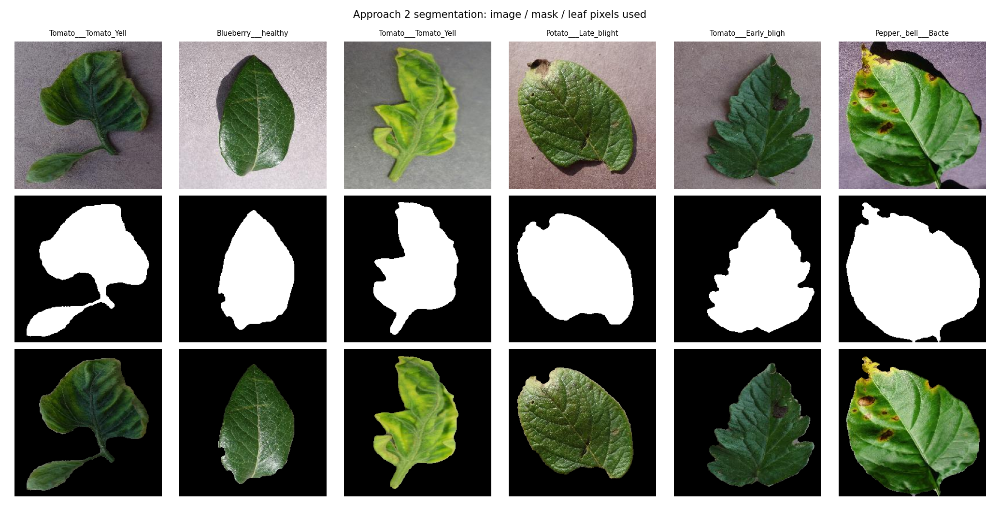

In [ ]:
from IPython.display import Image, display
display(Image('outputs/figures/a2_segmentation.png'))

## 9. Approach 2 — the real run

Colab gives 2 vCPUs, so extraction is the slow part (~10-15 min for 400 images
per class). Features are cached to `outputs/features/*.npz`, so rerunning the
models afterwards costs nothing.

In [ ]:
# !python src/approach2_handcrafted.py --max-per-class 400 --n-jobs 2 2>&1 | tee outputs/a2_log.txt

In [ ]:
!python src/approach2_handcrafted.py --max-per-class 400 --n-jobs 2 --skip-rf 2>&1 | tee outputs/a2_svm_log.txt

[features] loaded cache /content/leaf_xai/outputs/features/a2_train_n400_s256.npz  X=(14046, 186)
[features] loaded cache /content/leaf_xai/outputs/features/a2_val_n400_s256.npz  X=(6953, 186)
[features] loaded cache /content/leaf_xai/outputs/features/a2_test_n400_s256.npz  X=(6953, 186)
[a2] 38 classes | train=14046 val=6953 test=6953 | 186 features

[a2] SVM: grid search over 9 configuration(s) ...
Fitting 1 folds for each of 9 candidates, totalling 9 fits
[a2] SVM: best val macro-F1 =0.8971 with {'svm__C': 100.0, 'svm__gamma': 0.001}  (178s)

=== A2 / SVM / test set ===
  accuracy          : 0.9243
  balanced accuracy : 0.9284
  macro F1          : 0.9185
  weighted F1       : 0.9245
  test images       : 6953
[utils] saved figure -> /content/leaf_xai/outputs/figures/a2_svm_confusion.png
[a2] SVM: group permutation importance (5 repeats on the test split) ...
  group  n_features  mean_f1_drop  std_f1_drop
  color         114      0.747554     0.004719
texture          58      0.5504

In [ ]:
!python src/approach2_handcrafted.py --max-per-class 400 --n-jobs 2 --skip-svm 2>&1 | tee outputs/a2_rf_log.txt

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[features] extracting 14046 images with n_jobs=2 ...
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:    1.7s
[Parallel(n_jobs=2)]: Done 204 tasks      | elapsed:    8.3s
[Parallel(n_jobs=2)]: Done 564 tasks      | elapsed:   16.6s
[Parallel(n_jobs=2)]: Done 1068 tasks      | elapsed:   30.4s
[Parallel(n_jobs=2)]: Done 1716 tasks      | elapsed:   47.5s
[Parallel(n_jobs=2)]: Done 2508 tasks      | elapsed:  1.2min
[Parallel(n_jobs=2)]: Done 3444 tasks      | elapsed:  1.6min
[Parallel(n_jobs=2)]: Done 4524 tasks      | elapsed:  2.1min
[Parallel(n_jobs=2)]: Done 5748 tasks      | elapsed:  2.6min
[Parallel(n_jobs=2)]: Done 7116 tasks      | elapsed:  3.2min
[Parallel(n_jobs=2)]: Done 8628 tasks      | elapsed:  3.9min
[Parallel(n_jobs=2)]: Done 10284 tasks      | elapsed:  4.7min
[Parallel(n_jobs=2)]: Done 12084 tasks      | elapsed:  5.5min
[Parallel(n_jobs=2)]: Done 14028 tasks      | elapsed:  6.3min
[Par

## 10. Approach 1 — EfficientNet-B0 first

B0 is the faster backbone, so run it first: if something is wrong with the data
you find out in 5 minutes instead of an hour.

In [ ]:
!python src/approach1_transfer.py --arch efficientnet_b0 --workers 2 2>&1 | tee outputs/a1_effnet_log.txt

[a1] device=cuda  amp=True  arch=efficientnet_b0
[a1] 38 classes | train=38013 val=8146 test=8146
[a1] epoch 01/15 (warmup) train_loss=1.2832 train_f1=0.8057 | val_loss=1.3916 val_f1=0.8932 (399s)
[a1]   new best val macro-F1 0.8932 -> saved a1_efficientnet_b0.pt
[a1] epoch 02/15 (warmup) train_loss=0.9702 train_f1=0.8919 | val_loss=1.3213 val_f1=0.9128 (350s)
[a1]   new best val macro-F1 0.9128 -> saved a1_efficientnet_b0.pt
[a1] epoch 03/15 (warmup) train_loss=0.9288 train_f1=0.9057 | val_loss=1.2898 val_f1=0.9233 (347s)
[a1]   new best val macro-F1 0.9233 -> saved a1_efficientnet_b0.pt
[a1] unfreezing backbone, switching to fine-tune LR
[a1] epoch 04/15 (finetune) train_loss=0.9050 train_f1=0.9120 | val_loss=1.0930 val_f1=0.9827 (393s)
[a1]   new best val macro-F1 0.9827 -> saved a1_efficientnet_b0.pt
[a1] epoch 05/15 (finetune) train_loss=0.7282 train_f1=0.9761 | val_loss=1.0261 val_f1=0.9902 (376s)
[a1]   new best val macro-F1 0.9902 -> saved a1_efficientnet_b0.pt
[a1] epoch 06/15

In [ ]:
!cp data/splits.csv data/classes.json /content/drive/MyDrive/csg520_outputs/

## 11. Approach 1 — ResNet50

In [ ]:
!python src/approach1_transfer.py --arch resnet50 --epochs 8 --workers 2 2>&1 | tee outputs/a1_resnet_log.txt

[a1] device=cuda  amp=True  arch=resnet50
[a1] 38 classes | train=38013 val=8146 test=8146
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 128MB/s]
[a1] epoch 01/11 (warmup) train_loss=1.4419 train_f1=0.7902 | val_loss=1.4401 val_f1=0.8882 (327s)
[a1]   new best val macro-F1 0.8882 -> saved a1_resnet50.pt
[a1] epoch 02/11 (warmup) train_loss=1.0175 train_f1=0.8871 | val_loss=1.3549 val_f1=0.9172 (330s)
[a1]   new best val macro-F1 0.9172 -> saved a1_resnet50.pt
[a1] epoch 03/11 (warmup) train_loss=0.9548 train_f1=0.9056 | val_loss=1.3055 val_f1=0.9219 (335s)
[a1]   new best val macro-F1 0.9219 -> saved a1_resnet50.pt
[a1] unfreezing backbone, switching to fine-tune LR
[a1] epoch 04/11 (finetune) train_loss=0.8295 train_f1=0.9433 | val_loss=1.0501 val_f1=0.9835 (369s)
[a1]   new best val macro-F1 0.9835 -> saved a1_resnet50.pt
[a1] epoch 05/11 (finetune) train_

## 12. The ablation that answers A1's question

Same architecture, random initialisation instead of ImageNet weights. Capped per
class so it finishes quickly -- for a fair comparison, run the pretrained version
with the **same** cap:

    python src/approach1_transfer.py --arch resnet50 --max-per-class 500

Then compare macro-F1 *and* the two Grad-CAM figures.

In [10]:
import pathlib

p = pathlib.Path('src/approach1_transfer.py')
s = p.read_text()

if '_scratch' in s:
    print('already patched, nothing to do')
else:
    edits = [
        ('    print(f"[a1] device={device}  amp={use_amp}  arch={args.arch}")',
         '    print(f"[a1] device={device}  amp={use_amp}  arch={args.arch}")\n\n'
         '    tag = f"a1_{args.arch}" + ("_scratch" if args.no_pretrained else "")\n'
         '    args.tag = tag'),
        ('    ckpt_path = config.CKPT_DIR / f"a1_{args.arch}.pt"',
         '    ckpt_path = config.CKPT_DIR / f"{tag}.pt"'),
        ('    utils.save_metrics(metrics, f"a1_{args.arch}")',
         '    utils.save_metrics(metrics, tag)'),
        ('    utils.plot_confusion_matrix(y_true, y_pred, classes, f"a1_{args.arch}_confusion")',
         '    utils.plot_confusion_matrix(y_true, y_pred, classes, f"{tag}_confusion")'),
        ('        utils.plot_training_curves(history, f"a1_{args.arch}_curves")',
         '        utils.plot_training_curves(history, f"{tag}_curves")'),
        ('        run_gradcam(model, loaders, classes, args.arch, device)',
         '        run_gradcam(model, loaders, classes, args.arch, device, tag=tag)'),
        ('def run_gradcam(model, loaders, classes, arch: str, device, n_images: int = 8) -> None:',
         'def run_gradcam(model, loaders, classes, arch: str, device, n_images: int = 8,\n'
         '                tag: str | None = None) -> None:'),
        ('        out_name=f"a1_{arch}_gradcam",',
         '        out_name=f"{tag or f\'a1_{arch}\'}_gradcam",'),
        ('    (config.METRIC_DIR / f"a1_{args.arch}_history.json").write_text(',
         '    (config.METRIC_DIR / f"{getattr(args, \'tag\', f\'a1_{args.arch}\')}_history.json").write_text('),
    ]
    for old, new in edits:
        assert s.count(old) == 1, f'NO MATCH: {old[:60]}'
        s = s.replace(old, new)
    p.write_text(s)
    print('patched OK')

patched OK


In [12]:
# !python src/approach1_transfer.py --arch resnet50 --no-pretrained --max-per-class 500 --workers 2 2>&1 | tee outputs/a1_scratch_log.txt
# !python src/approach1_transfer.py --arch resnet50 --no-pretrained --warmup-epochs 0 --epochs 11 --workers 2 2>&1 | tee outputs/a1_scratch_log.txt
!python src/approach1_transfer.py --arch resnet50 --no-pretrained --warmup-epochs 0 --epochs 11 --workers 12 2>&1 | tee outputs/a1_scratch_log.txt

[a1] device=cuda  amp=True  arch=resnet50
[a1] 38 classes | train=38013 val=8146 test=8146
[a1] unfreezing backbone, switching to fine-tune LR
[a1] epoch 01/11 (finetune) train_loss=2.5669 train_f1=0.3316 | val_loss=2.0967 val_f1=0.5933 (102s)
[a1]   new best val macro-F1 0.5933 -> saved a1_resnet50_scratch.pt
[a1] epoch 02/11 (finetune) train_loss=1.5307 train_f1=0.6365 | val_loss=1.6412 val_f1=0.7492 (102s)
[a1]   new best val macro-F1 0.7492 -> saved a1_resnet50_scratch.pt
[a1] epoch 03/11 (finetune) train_loss=1.1983 train_f1=0.7690 | val_loss=1.4110 val_f1=0.8682 (103s)
[a1]   new best val macro-F1 0.8682 -> saved a1_resnet50_scratch.pt
[a1] epoch 04/11 (finetune) train_loss=1.0434 train_f1=0.8341 | val_loss=1.3309 val_f1=0.8788 (102s)
[a1]   new best val macro-F1 0.8788 -> saved a1_resnet50_scratch.pt
[a1] epoch 05/11 (finetune) train_loss=0.9384 train_f1=0.8780 | val_loss=1.2470 val_f1=0.9133 (102s)
[a1]   new best val macro-F1 0.9133 -> saved a1_resnet50_scratch.pt
[a1] epoch 0

In [ ]:
!python src/approach1_transfer.py --arch resnet50 --no-pretrained --eval-only --workers 2

[a1] device=cpu  amp=False  arch=resnet50
[a1] 38 classes | train=38013 val=8146 test=8146

=== A1 / resnet50 / test set ===
  accuracy          : 0.9574
  balanced accuracy : 0.9633
  macro F1          : 0.9449
  weighted F1       : 0.9581
  top-5 accuracy    : 0.9977
  test images       : 8146
[utils] saved metrics -> /content/leaf_xai/outputs/metrics/a1_resnet50_scratch.json
[utils] saved figure -> /content/leaf_xai/outputs/figures/a1_resnet50_scratch_confusion.png
[gradcam] saved figure -> /content/leaf_xai/outputs/figures/a1_resnet50_scratch_gradcam.png


In [ ]:
import json, pathlib
p = pathlib.Path('outputs/metrics/a1_resnet50.json')
m = json.load(p.open())
m['pretrained'] = True
json.dump(m, p.open('w'), indent=2)
print('fixed')

fixed


GO BACK AND RUN SVM


## 13. Look at the figures

a1_efficientnet_b0_confusion.png


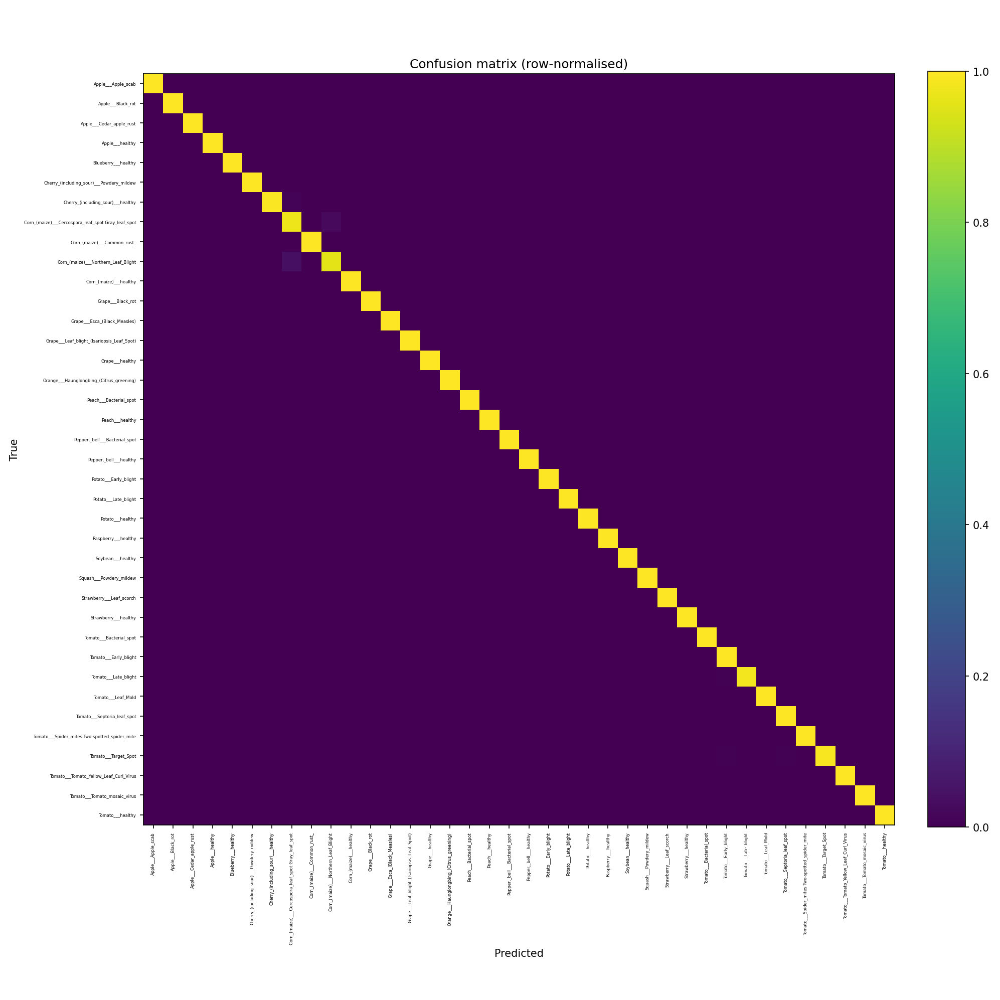

a1_efficientnet_b0_curves.png


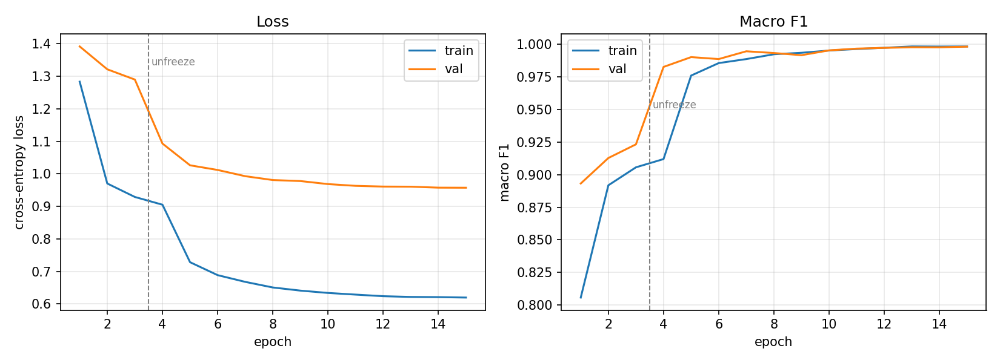

a1_efficientnet_b0_gradcam.png


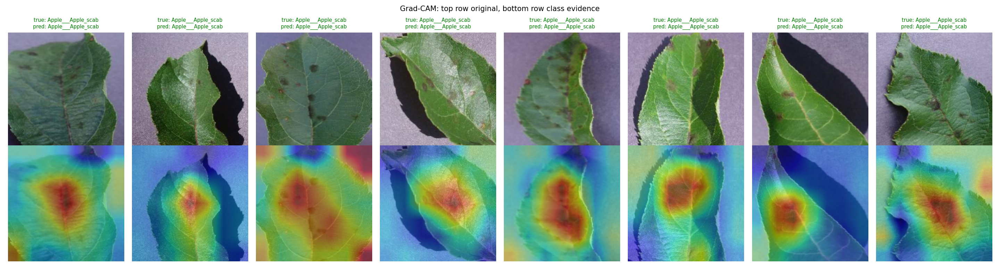

a1_resnet50_confusion.png


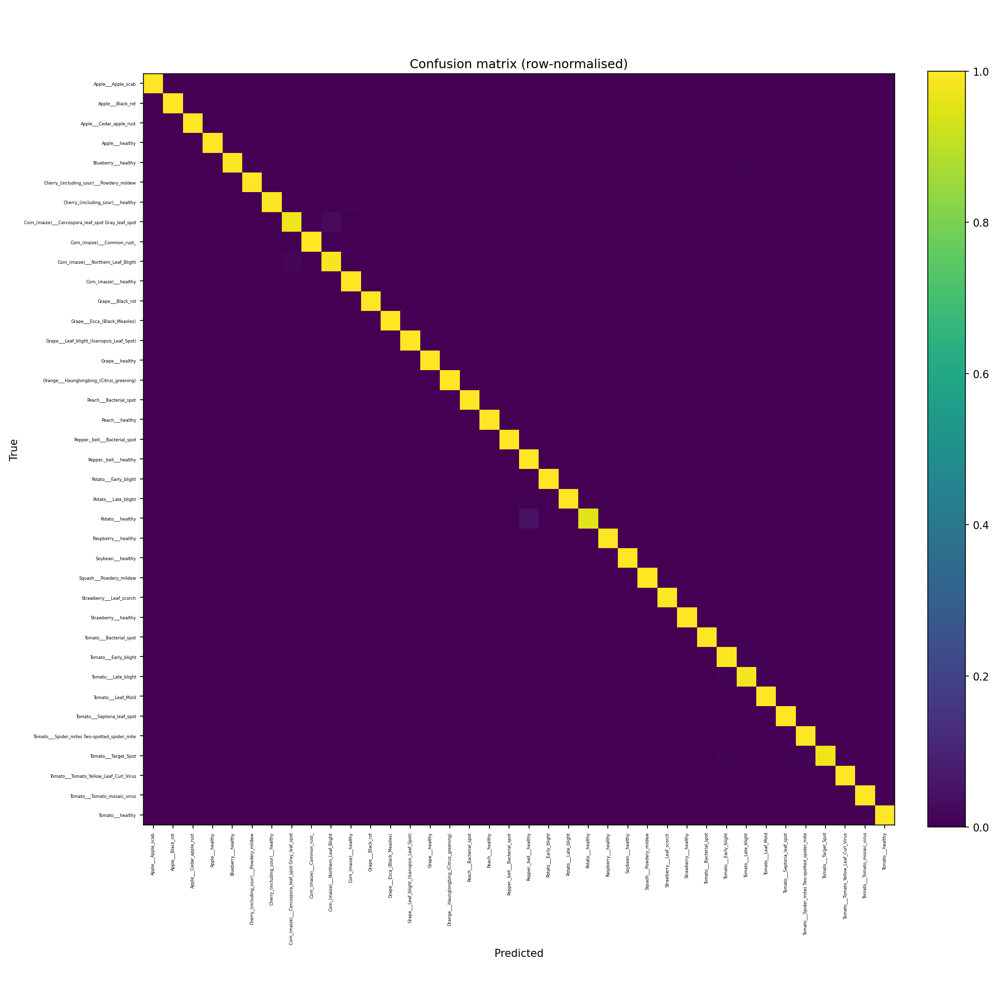

a1_resnet50_curves.png


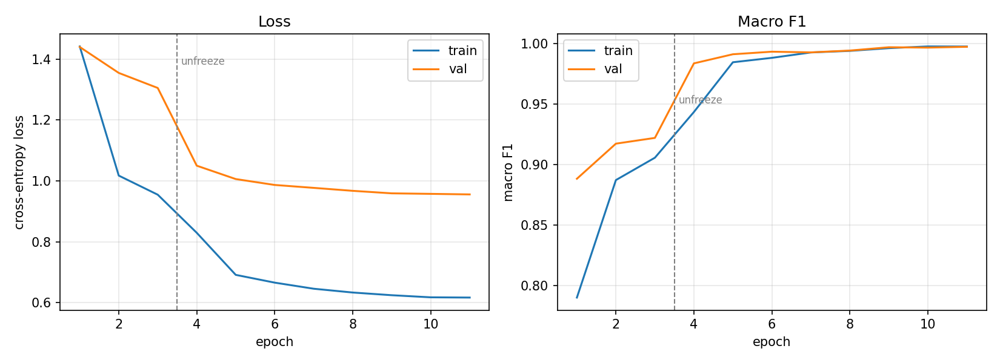

a1_resnet50_gradcam.png


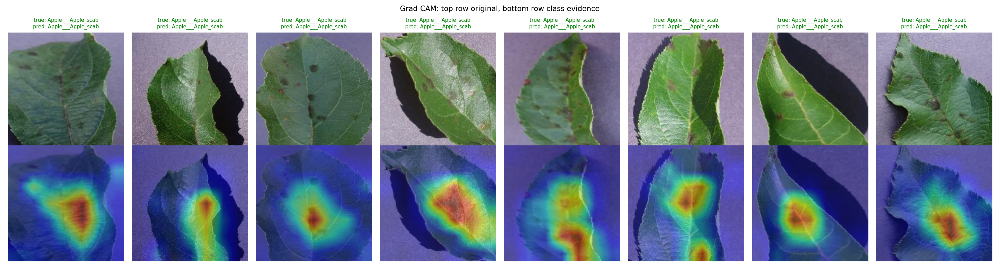

a1_resnet50_scratch_confusion.png


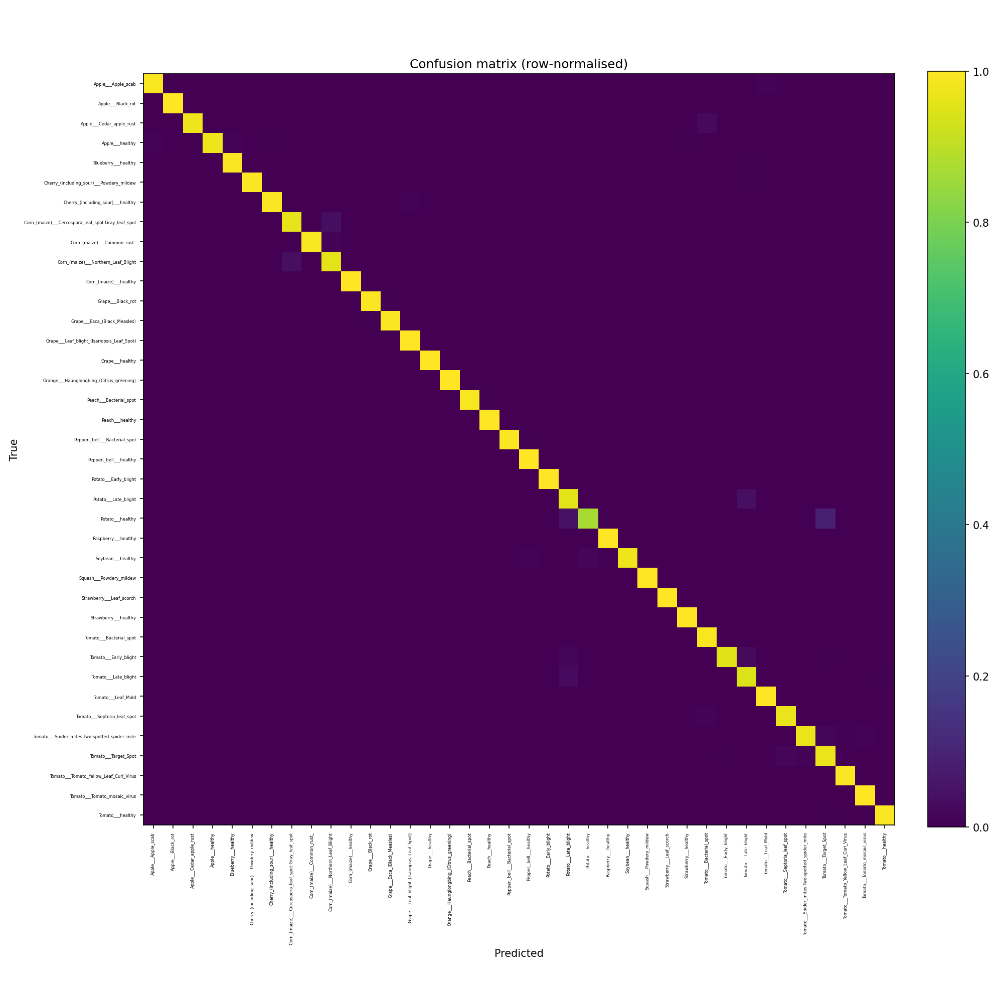

a1_resnet50_scratch_curves.png


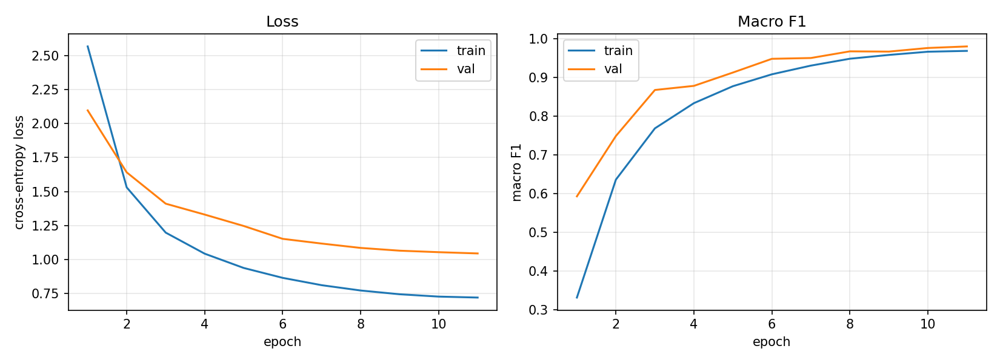

a1_resnet50_scratch_gradcam.png


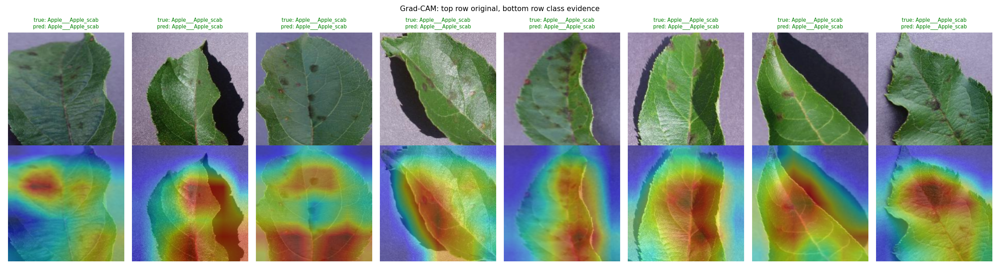

a2_rf_confusion.png


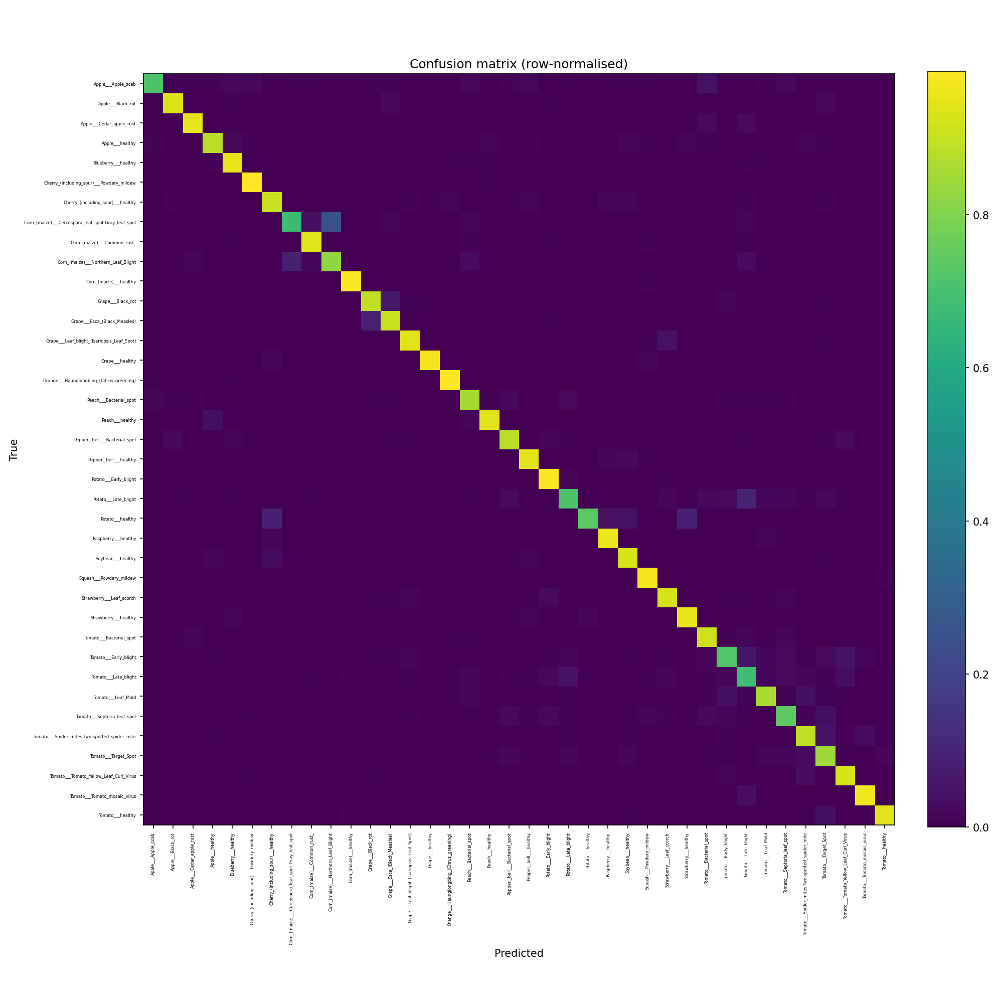

a2_rf_feature_importance.png


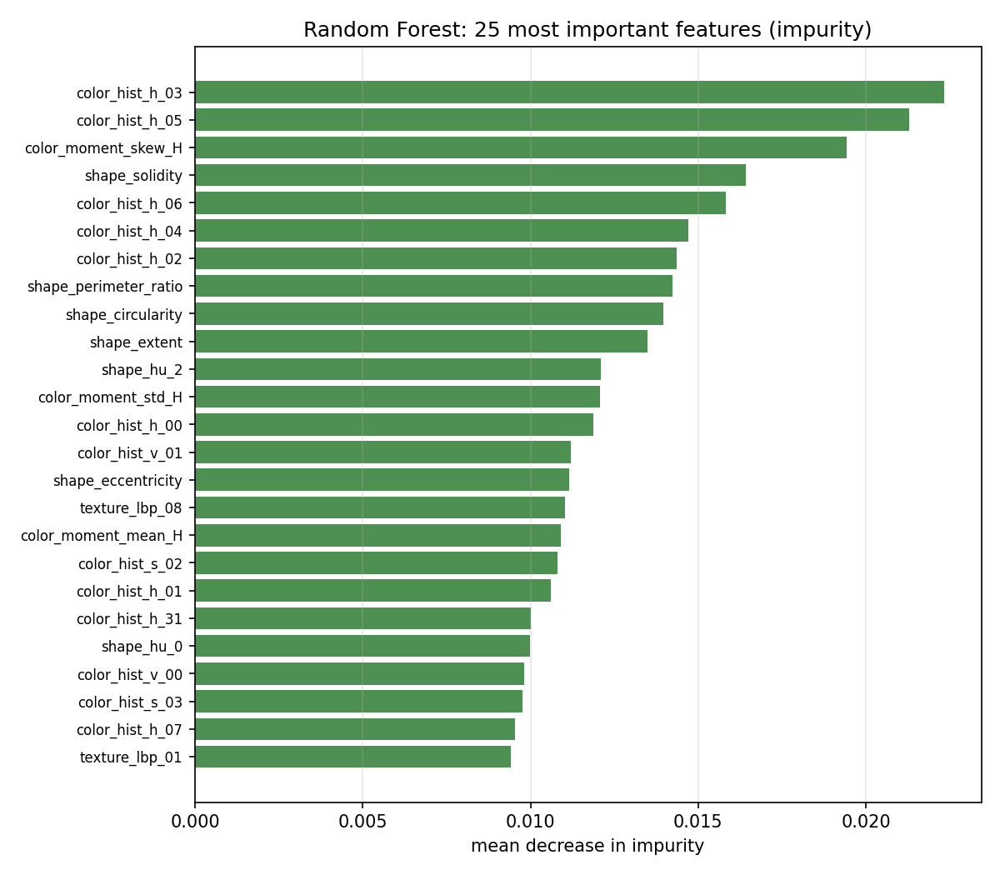

a2_rf_group_permutation.png


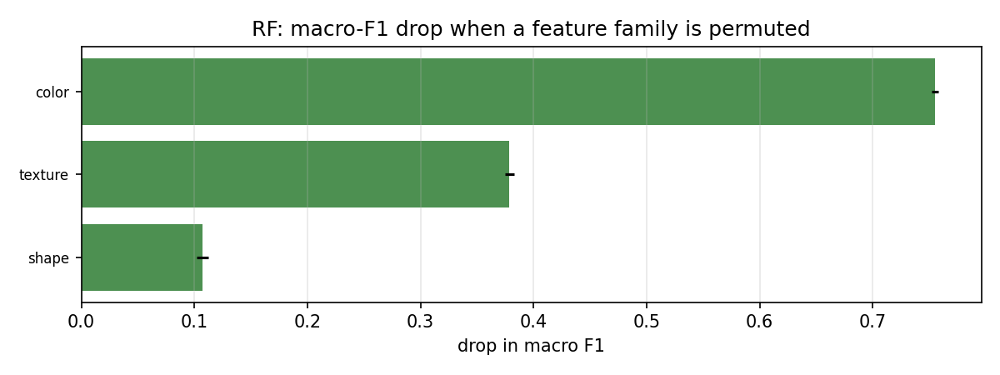

a2_segmentation.png


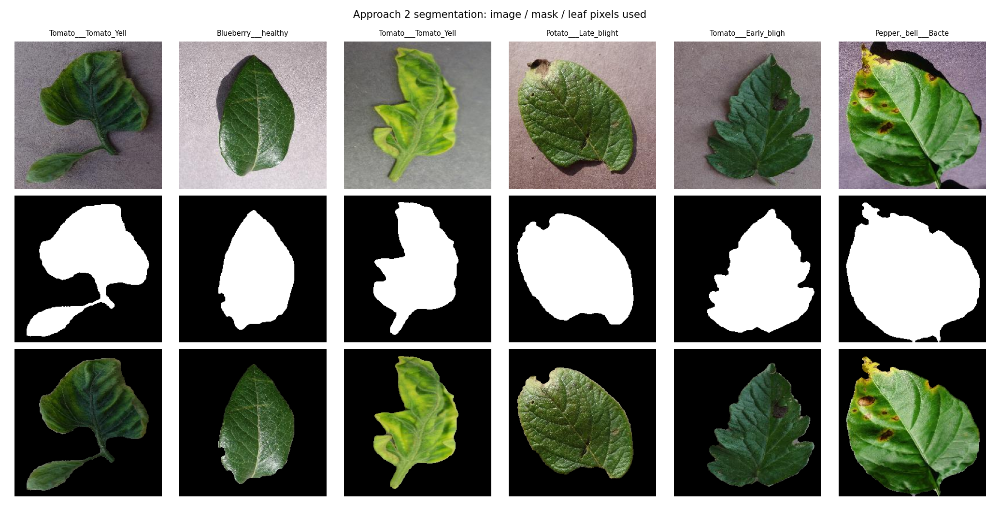

a2_svm_confusion.png


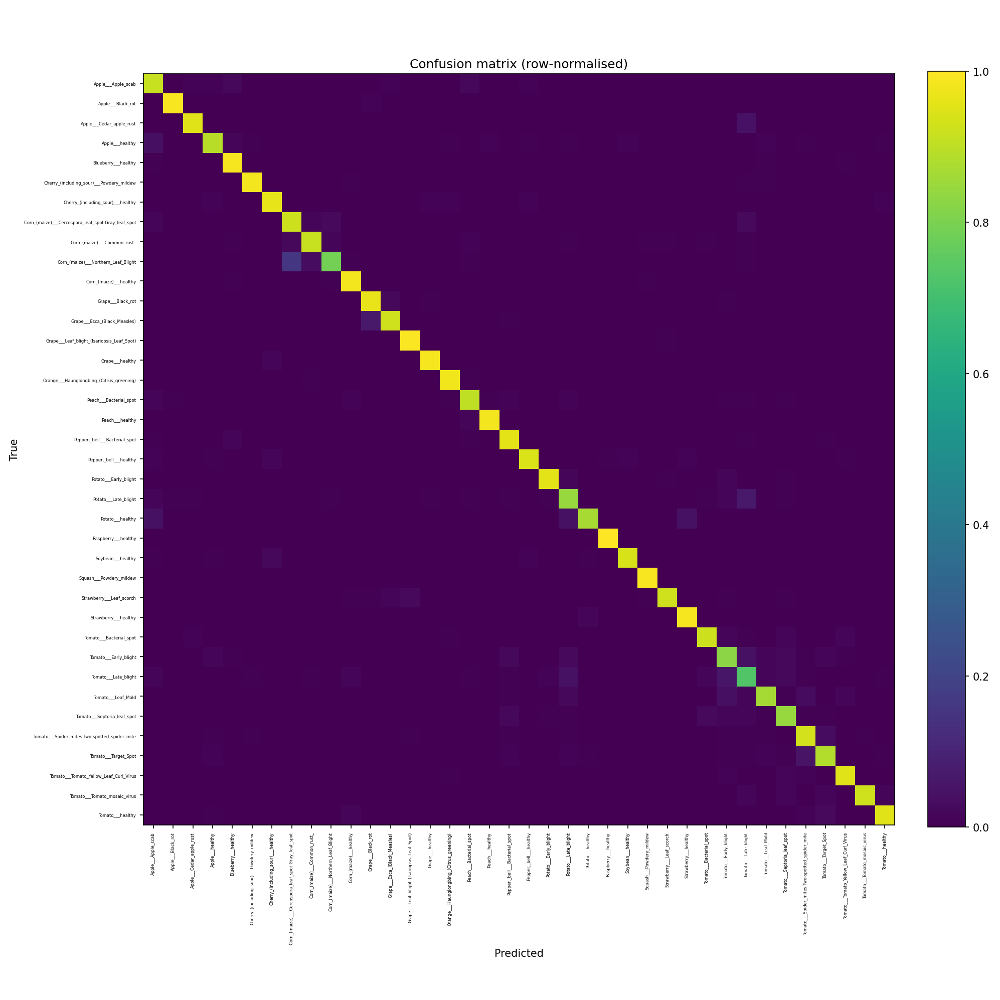

a2_svm_group_permutation.png


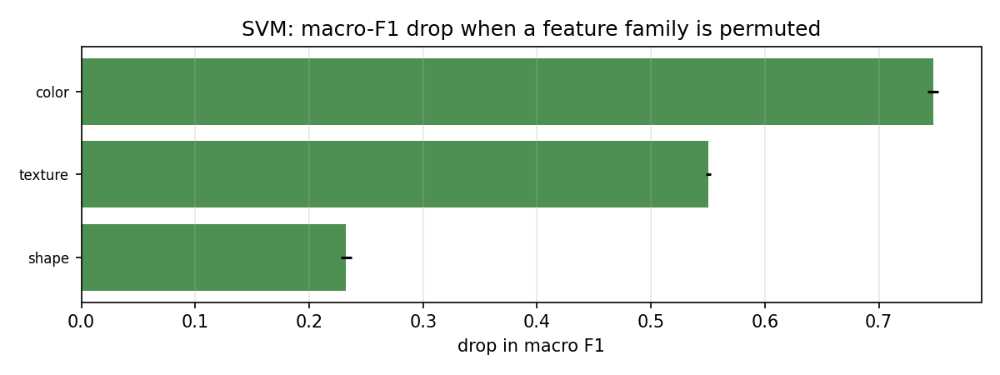

In [13]:
from IPython.display import Image, display
import glob, os

for path in sorted(glob.glob('outputs/figures/*.png')):
    print(os.path.basename(path))
    display(Image(path))

## 14. Collect the numbers for the results table

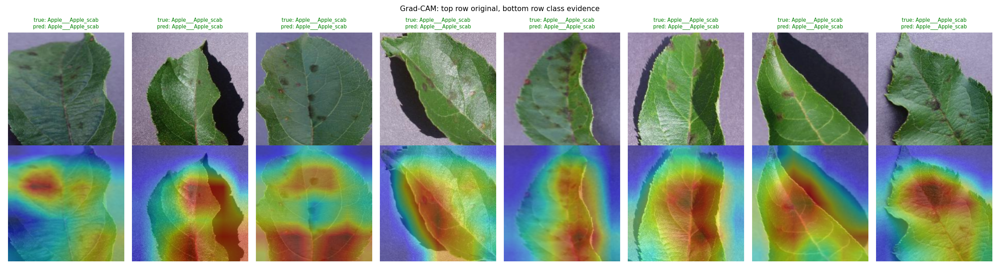

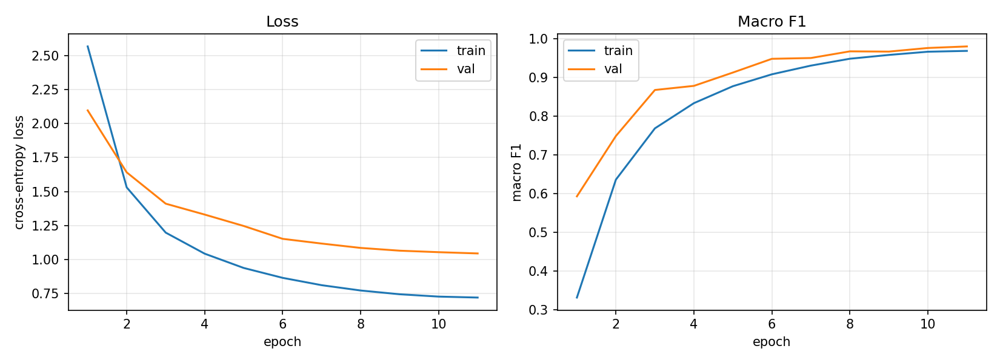

In [14]:
from IPython.display import Image, display
display(Image('outputs/figures/a1_resnet50_scratch_gradcam.png'))
display(Image('outputs/figures/a1_resnet50_scratch_curves.png'))

In [ ]:
import json, glob, os
import pandas as pd

rows = []
for path in sorted(glob.glob('outputs/metrics/a*.json')):
    if path.endswith('_history.json'):
        continue
    m = json.load(open(path))
    if 'accuracy' not in m:
        continue
    rows.append({
        'run': os.path.basename(path).replace('.json', ''),
        'approach': m.get('approach'),
        'model': m.get('architecture') or m.get('model'),
        'pretrained': m.get('pretrained', '-'),
        'accuracy': round(m['accuracy'], 4),
        'balanced_acc': round(m['balanced_accuracy'], 4),
        'macro_F1': round(m['macro_f1'], 4),
        'test_n': m['n_samples'],
    })

table = pd.DataFrame(rows)
table.to_csv('outputs/metrics/summary_table.csv', index=False)
table


,run,approach,model,pretrained,accuracy,balanced_acc,macro_F1,test_n
0,a1_efficientnet_b0,A1_transfer_learning,efficientnet_b0,True,0.9978,0.9972,0.9967,8146
1,a1_resnet50,A1_transfer_learning,resnet50,True,0.9974,0.9960,0.9963,8146
2,a1_resnet50_scratch,A1_transfer_learning,resnet50,False,0.9574,0.9633,0.9449,8146
3,a2_rf,A2_handcrafted_features,RF,-,0.8916,0.8877,0.8811,6953
4,a2_svm,A2_handcrafted_features,SVM,-,0.9243,0.9284,0.9185,6953


In [15]:
import json, glob, os
import pandas as pd

rows = []
for path in sorted(glob.glob('outputs/metrics/a*.json')):
    if path.endswith('_history.json'):
        continue
    m = json.load(open(path))
    if 'accuracy' not in m:
        continue
    rows.append({
        'run': os.path.basename(path).replace('.json', ''),
        'approach': m.get('approach'),
        'model': m.get('architecture') or m.get('model'),
        'pretrained': m.get('pretrained', '-'),
        'accuracy': round(m['accuracy'], 4),
        'balanced_acc': round(m['balanced_accuracy'], 4),
        'macro_F1': round(m['macro_f1'], 4),
        'test_n': m['n_samples'],
    })

table = pd.DataFrame(rows)
table.to_csv('outputs/metrics/summary_table.csv', index=False)
table


,run,approach,model,pretrained,accuracy,balanced_acc,macro_F1,test_n
0,a1_efficientnet_b0,A1_transfer_learning,efficientnet_b0,True,0.9978,0.9972,0.9967,8146
1,a1_resnet50,A1_transfer_learning,resnet50,True,0.9974,0.9960,0.9963,8146
2,a1_resnet50_scratch,A1_transfer_learning,resnet50,False,0.9866,0.9843,0.9792,8146
3,a2_rf,A2_handcrafted_features,RF,-,0.8916,0.8877,0.8811,6953
4,a2_svm,A2_handcrafted_features,SVM,-,0.9243,0.9284,0.9185,6953


In [ ]:
import numpy as np, config
cm = np.loadtxt('outputs/metrics/a1_resnet50_confusion_counts.csv', delimiter=',').astype(int)
classes = config.load_classes()

err = [(cm[i, j], classes[i], classes[j], int(cm[i].sum()))
       for i in range(len(classes)) for j in range(len(classes))
       if i != j and cm[i, j] > 0]

for c, t, p, n in sorted(err, reverse=True):
    print(f'{c:2d} of {n:4d}   {t:52s} -> {p}')
print('\ntotal errors:', sum(e[0] for e in err), '| pairs:', len(err))

 3 of  287   Tomato___Late_blight                                 -> Tomato___Early_blight
 2 of  211   Tomato___Target_Spot                                 -> Tomato___Spider_mites Two-spotted_spider_mite
 2 of  211   Tomato___Target_Spot                                 -> Tomato___Early_blight
 2 of  147   Corn_(maize)___Northern_Leaf_Blight                  -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 2 of   77   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   -> Corn_(maize)___Northern_Leaf_Blight
 1 of  211   Tomato___Target_Spot                                 -> Tomato___Septoria_leaf_spot
 1 of  287   Tomato___Late_blight                                 -> Tomato___healthy
 1 of  287   Tomato___Late_blight                                 -> Tomato___Leaf_Mold
 1 of  150   Tomato___Early_blight                                -> Tomato___Late_blight
 1 of  319   Tomato___Bacterial_spot                              -> Tomato___Early_blight
 1 of  764   Soybean___hea

## 15. Download everything

Outputs are already in Drive (`MyDrive/csg520_outputs`). This just gives you a
local zip too.

In [ ]:
!cd /content && zip -rq results.zip /content/drive/MyDrive/csg520_outputs
from google.colab import files
files.download('/content/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## If the runtime disconnects mid-training

The best checkpoint so far is already in Drive, so nothing is lost, but training
does not resume from where it stopped. Options:

- Score what you have: `!python src/approach1_transfer.py --arch resnet50 --eval-only`
- Restart with a shorter schedule: `--epochs 8`
- Or cap the data: `--max-per-class 800`

Keep the tab open and the machine awake; free Colab disconnects an idle session
after roughly 90 minutes.